# 03 — Machine learning : entraînement & comparaison

XGBoost Ranker en **Leave-One-Commit-Out CV**, importance des features, comparaison aux baselines et aux autres modèles (RF, LogReg, LightGBM, RankNet).

**Entrée** : `artifacts/dataset_features.pkl`.  
**Sortie** : `artifacts/dataset_scored.pkl` + modèles entraînés dans `models/` (.pkl).

In [1]:
# Chemins relatifs au package (portable) 
from pathlib import Path
import os
ROOT = Path.cwd()
if ROOT.name == 'scripts':
    ROOT = ROOT.parent          
elif (ROOT / 'scripts').exists():
    pass                        
DATA = ROOT / 'data'
ARTIFACTS = ROOT / 'artifacts'
MODELS = ROOT / 'models'
ARTIFACTS.mkdir(exist_ok=True); MODELS.mkdir(exist_ok=True)
print('Racine du package :', ROOT)

Racine du package : c:\Users\LEGION\OneDrive\Bureau\package_evaluation


In [2]:
import pandas as pd, numpy as np, pickle
import warnings; warnings.filterwarnings('ignore'); np.random.seed(42)
df = pd.read_pickle(ARTIFACTS/'dataset_features.pkl')
print('Features chargées :', df.shape)

Features chargées : (263649, 31)


## XGBoost Ranker — Leave-One-Commit-Out CV

In [5]:
# ÉTAPE 10 : XGBoost Ranker + Leave-One-Commit-Out 
import xgboost as xgb
from sklearn.metrics import ndcg_score

FEATURES = [
    'commit_nb_files', 'commit_lines_added', 'commit_lines_deleted',
    'commit_lines_total', 'module_touched', 'module_dependency_touched',
    'test_file_touched', 'filename_kw_count', 'has_filename_kw',
    'duration_ms', 'is_slow_test', 'test_name_length', 'method_name_length',
    'module_rel_hist', 'test_rel_hist', 'nb_past_commits',
    'tfidf_score', 'tfidf_count', 'has_tfidf_kw', 'similarity_score',
]

def score_to_grade(s):

    """Convertit un score de pertinence continu [0,1] en grade discret [0,5].

    XGBoost Ranker s'entraîne sur des grades entiers de pertinence (relevance
    grades) plutôt que sur des scores continus. Le seuil bas fixé à 0,15
    implique que les tests faiblement liés (score 0,1, module dépendant) sont
    assimilés au grade 0.

    Args:
        s: Score de pertinence continu.

    Returns:
        Grade entier de 0 (non pertinent) à 5 (directement modifié).
    """

    if s >= 1.0:  return 5
    if s >= 0.8:  return 4
    if s >= 0.5:  return 3
    if s >= 0.3:  return 2
    if s >= 0.15: return 1
    return 0

def compute_apfd(ordered_labels):

    """Calcule l'APFD (Average Percentage of Faults Detected) d'un classement.

    Mesure la capacité d'un ordonnancement à détecter tôt les tests pertinents :
    plus les tests pertinents sont placés en tête, plus l'APFD est élevé.

    Args:
        ordered_labels: Liste binaire (1 = pertinent, 0 sinon) dans l'ordre
            du classement évalué.

    Returns:
        Valeur d'APFD dans [0,1]. Retourne 0.5 si le classement est vide ou
        ne contient aucun test pertinent (cas non discriminant).
    """

    n, m = len(ordered_labels), sum(ordered_labels)
    if m == 0 or n == 0: return 0.5
    pos = [i+1 for i, l in enumerate(ordered_labels) if l == 1]
    return 1 - sum(pos)/(n*m) + 1/(2*n)

def safe_ndcg(y_true, y_score, k=None):
    """Calcule le NDCG de manière robuste.

    Encapsule ndcg_score de scikit-learn en renvoyant 0.0 lorsque la métrique
    n'est pas calculable (par exemple lorsqu'il n'y a qu'un seul échantillon
    ou aucune pertinence), évitant ainsi d'interrompre la boucle de validation.

    Args:
        y_true: Pertinences réelles.
        y_score: Scores prédits.
        k: Profondeur de troncature (None = classement complet).

    Returns:
        Valeur de NDCG, ou 0.0 si non calculable.
    """
    try:
        return ndcg_score(y_true.reshape(1, -1), y_score.reshape(1, -1), k=k)
    except Exception:
        return 0.0

# Baselines
df['random_score'] = np.random.random(len(df))
df['module_score'] = df['module_touched'].astype(float) + np.random.random(len(df)) * 0.01

APPROACHES = [
    ('random_score', 'Aléatoire'),
    ('module_score', 'Module seul'),
    ('similarity_score', 'SBERT seul'),
    ('rank_score', 'Ranker hybride'),
]

# Leave-One-Commit-Out CV
commit_ids = df.commit_id.unique().tolist()
df['rank_score'] = 0.0
all_importances = []

print('LEAVE-ONE-COMMIT-OUT CROSS-VALIDATION (30 folds)')

fold_results = {}

for fold_i, test_cid in enumerate(commit_ids):
    df_tr = df[df.commit_id != test_cid].copy()
    df_te = df[df.commit_id == test_cid].copy()

    # On écarte les commits dont tous les tests partagent le même label :
    # l'APFD et le NDCG y sont indéfinis ou non discriminants.
    if df_te.label_relevant.sum() == 0 or df_te.label_relevant.nunique() < 2:
        print(f"\n  Fold {fold_i+1:>2}/30 [{test_cid}]: skip (pas de labels mixtes)")
        continue

    # Préparation des matrices d'entraînement et de test.
    # Les labels sont convertis en grades ; XGBRanker a besoin de la taille
    # de chaque groupe (un groupe = un commit) pour apprendre par requête.

    X_tr = df_tr[FEATURES].values
    y_tr = df_tr['relevance_score'].apply(score_to_grade).values
    X_te = df_te[FEATURES].values
    tr_groups = df_tr.groupby('commit_id').size().values

    # Modèle XGBoost Ranker. Les hyperparamètres (profondeur faible,
    # régularisation, sous-échantillonnage) limitent le surapprentissage
    # sur un dataset de taille modérée.
    ranker = xgb.XGBRanker(
        objective='rank:pairwise', n_estimators=200, max_depth=3,
        learning_rate=0.05, subsample=0.7, colsample_bytree=0.7,
        reg_alpha=1.0, reg_lambda=2.0, min_child_weight=10,
        random_state=42, verbosity=0,
    )
    ranker.fit(X_tr, y_tr, group=tr_groups, verbose=False)
    preds = ranker.predict(X_te)
    df.loc[df.commit_id == test_cid, 'rank_score'] = preds
    all_importances.append(ranker.feature_importances_)

    #Évaluation
    dc = df[df.commit_id == test_cid].copy()
    n_pert = int(dc.label_relevant.sum())
    y_rel = dc['relevance_score'].values

    # Modèle XGBoost Ranker. Les hyperparamètres (profondeur faible,
    # régularisation, sous-échantillonnage) limitent le surapprentissage
    # sur un dataset de taille modérée.
    results = {}
    for col, name in APPROACHES:
        ordered = dc.sort_values(col, ascending=False)['label_relevant'].tolist()
        apfd = compute_apfd(ordered)
        y_sc = dc[col].values
        results[col] = {
            'apfd':     apfd,
            'ndcg20':   safe_ndcg(y_rel, y_sc, k=20),
            'ndcg_pert': safe_ndcg(y_rel, y_sc, k=n_pert), 
            'ndcg_full': safe_ndcg(y_rel, y_sc, k=None),     
        }

    fold_results[test_cid] = results
    print(f"\n  Fold {fold_i+1:>2}/30 [{test_cid}] — {len(dc):,} tests, {n_pert} pertinents")
    for col, name in APPROACHES:
        r = results[col]
        print(f"    {name:<18}: APFD={r['apfd']:.4f}  "
            f"NDCG@20={r['ndcg20']:.4f}  NDCG@{n_pert}={r['ndcg_pert']:.4f}  "
            f"NDCG_full={r['ndcg_full']:.4f}")

# ── Moyennes ──
print('MOYENNES LOO-CV')
for col, name in APPROACHES:
    if not fold_results: break
    apfds = [r[col]['apfd']      for r in fold_results.values()]
    n20   = [r[col]['ndcg20']    for r in fold_results.values()]
    npert = [r[col]['ndcg_pert'] for r in fold_results.values()]
    nfull = [r[col]['ndcg_full'] for r in fold_results.values()]
    # Référence aléatoire pour exprimer le gain relatif en APFD
    ba = np.mean([r['random_score']['apfd'] for r in fold_results.values()])
    print(f"  {name:<18}: APFD={np.mean(apfds):.4f} ({(np.mean(apfds)-ba):+.1%} vs rand)  "
        f"NDCG@20={np.mean(n20):.4f}  NDCG@nb_pert={np.mean(npert):.4f}  "
        f"NDCG_full={np.mean(nfull):.4f}")


LEAVE-ONE-COMMIT-OUT CROSS-VALIDATION (30 folds)

  Fold  1/30 [commit01] — 8,744 tests, 392 pertinents
    Aléatoire         : APFD=0.5100  NDCG@20=0.2253  NDCG@392=0.1564  NDCG_full=0.7403
    Module seul       : APFD=0.8684  NDCG@20=0.3431  NDCG@392=0.5176  NDCG_full=0.8864
    SBERT seul        : APFD=0.8141  NDCG@20=0.2785  NDCG@392=0.4700  NDCG_full=0.8549
    Ranker hybride    : APFD=0.8970  NDCG@20=0.9190  NDCG@392=0.6208  NDCG_full=0.9345

  Fold  2/30 [commit02] — 8,768 tests, 229 pertinents
    Aléatoire         : APFD=0.5082  NDCG@20=0.0000  NDCG@229=0.0269  NDCG_full=0.5461
    Module seul       : APFD=0.9851  NDCG@20=0.6105  NDCG@229=0.9275  NDCG_full=0.8917
    SBERT seul        : APFD=0.7886  NDCG@20=0.4186  NDCG@229=0.2807  NDCG_full=0.7118
    Ranker hybride    : APFD=0.9766  NDCG@20=1.0000  NDCG@229=0.8660  NDCG_full=0.9337

  Fold  3/30 [commit03] — 8,616 tests, 447 pertinents
    Aléatoire         : APFD=0.5029  NDCG@20=0.0191  NDCG@447=0.0596  NDCG_full=0.5938
   

## visulaisation de l'évolution du NDCG 

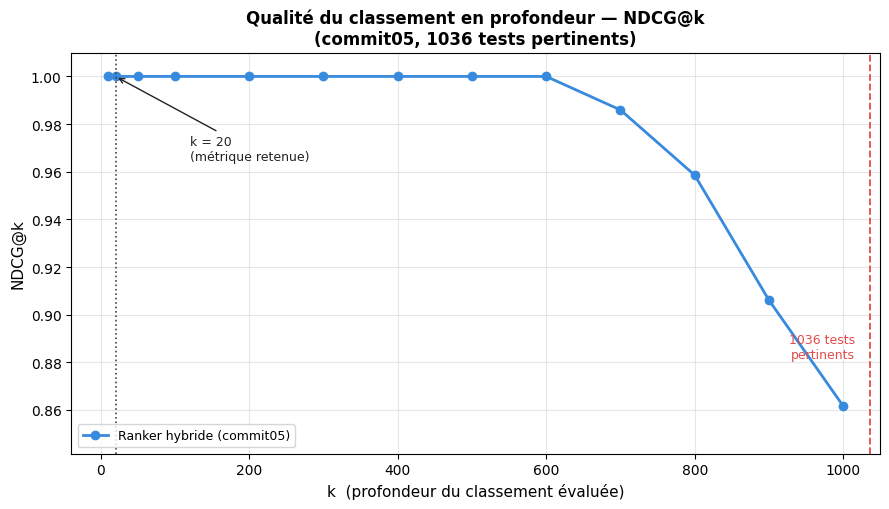

  NDCG@10   : 1.0000
  NDCG@20   : 1.0000
  NDCG@50   : 1.0000
  NDCG@100  : 1.0000
  NDCG@200  : 1.0000
  NDCG@300  : 1.0000
  NDCG@400  : 1.0000
  NDCG@500  : 1.0000
  NDCG@600  : 1.0000
  NDCG@700  : 0.9859
  NDCG@800  : 0.9585
  NDCG@900  : 0.9061
  NDCG@1000 : 0.8616


In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import ndcg_score

# Commit dense choisi pour illustrer l'évolution du NDCG en profondeur :
# commit05 compte 1036 tests pertinents, ce qui permet de tracer la courbe
# sur une large plage de k.
cid = 'commit05'   # 1036 tests pertinents
dc = df[df.commit_id == cid].copy()
n_pert = int(dc.label_relevant.sum())

# Pertinences réelles et scores prédits par le ranker, mis au format attendu
# par ndcg_score (une seule "requête", d'où le reshape en (1, -1)).
y_true = dc['relevance_score'].values.reshape(1, -1)
y_pred = dc['rank_score'].values.reshape(1, -1)

# Calcul du NDCG à des profondeurs croissantes : on observe comment la qualité
# du classement évolue à mesure que l'on évalue plus loin dans la liste.
ks = [10, 20, 50, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
ndcgs = [ndcg_score(y_true, y_pred, k=k) for k in ks]

# ── Figure : courbe NDCG@k ──
fig, ax = plt.subplots(figsize=(9, 5.2))
ax.plot(ks, ndcgs, marker='o', color='#378ADD', linewidth=2, markersize=6,
        label=f'Ranker hybride ({cid})')

# Repère vertical sur le nombre de tests pertinents : au-delà de ce point,
# le NDCG ne peut que se stabiliser ou décroître (tous les pertinents sont vus).
ax.axvline(n_pert, color='#E24B4A', linestyle='--', linewidth=1.3)
ax.text(n_pert - 20, min(ndcgs) + 0.02, f'{n_pert} tests\npertinents',
        ha='right', fontsize=9, color='#E24B4A')

# Repère vertical sur k = 20 : la profondeur retenue comme métrique principale
# (NDCG@20), correspondant à la zone réellement consultée par un développeur.
ax.axvline(20, color='#444', linestyle=':', linewidth=1.2)
ax.annotate('k = 20\n(métrique retenue)', xy=(20, 1.0), xytext=(120, 0.965),
        fontsize=9, color='#222',
        arrowprops=dict(arrowstyle='->', color='#222', lw=1))

# Mise en forme des axes, titre, légende
ax.set_xlabel('k  (profondeur du classement évaluée)', fontsize=11)
ax.set_ylabel('NDCG@k', fontsize=11)
ax.set_title(f'Qualité du classement en profondeur — NDCG@k\n({cid}, {n_pert} tests pertinents)',
        fontweight='bold', fontsize=12)
ax.set_ylim(min(ndcgs) - 0.02, 1.01)
ax.grid(alpha=0.3)
ax.legend(loc='lower left', fontsize=9)
plt.tight_layout()
# Sauvegarde de la figure pour le mémoire et le package de réplication
plt.savefig(ARTIFACTS / 'ndcg_at_k.png', dpi=150, bbox_inches='tight')
plt.show()

# Affichage des valeurs numériques de NDCG@k
for k, v in zip(ks, ndcgs):
        print(f"  NDCG@{k:<4} : {v:.4f}")

In [7]:
from sklearn.metrics import ndcg_score

# Comparaison des trois profondeurs de NDCG sur un commit dense (commit05),
# illustrant que le choix de k modifie la lecture de la performance :
#   - NDCG@20         : qualité du haut de classement (usage réel du développeur)
#   - NDCG@nb_pert    : qualité sur l'ensemble des tests pertinents (plus exigeant)
#   - NDCG complet    : qualité sur toute la liste (optimiste, queue peu pondérée)
cid = 'commit05'
dc = df[df.commit_id == cid].copy()
n_pert = int(dc.label_relevant.sum())

y_true = dc['relevance_score'].values.reshape(1, -1)
y_pred = dc['rank_score'].values.reshape(1, -1)

print(f"{cid} — {n_pert} tests pertinents sur {len(dc)}")
print(f"  NDCG@20            : {ndcg_score(y_true, y_pred, k=20):.4f}   (vision pratique)")
print(f"  NDCG@{n_pert} (=nb pert.) : {ndcg_score(y_true, y_pred, k=n_pert):.4f}   (tous les pertinents)")
print(f"  NDCG complet       : {ndcg_score(y_true, y_pred):.4f}   (toute la liste)")

commit05 — 1036 tests pertinents sur 8610
  NDCG@20            : 1.0000   (vision pratique)
  NDCG@1036 (=nb pert.) : 0.8465   (tous les pertinents)
  NDCG complet       : 0.9840   (toute la liste)


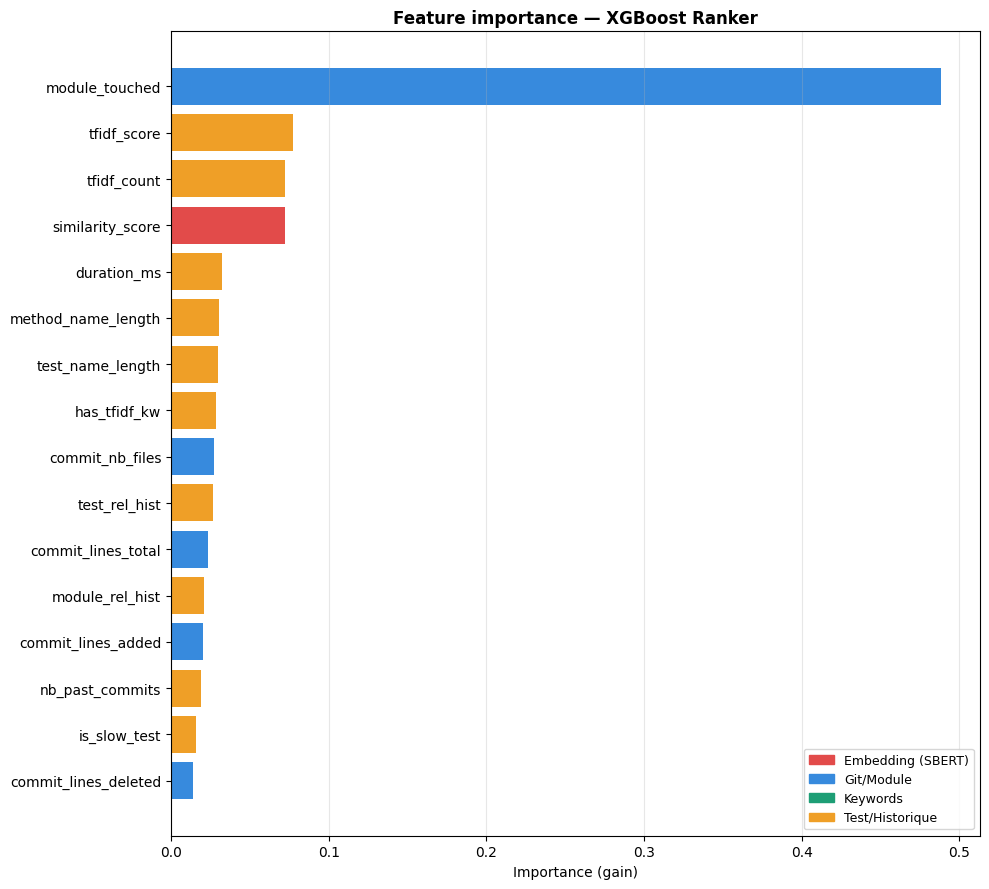


Top 5 features :
  duration_ms                   : 0.0324 (3.2%)
  similarity_score              : 0.0722 (7.2%)
  tfidf_count                   : 0.0726 (7.3%)
  tfidf_score                   : 0.0776 (7.8%)
  module_touched                : 0.4886 (48.9%)


In [8]:
# ÉTAPE 11 : Feature importance (moyenne des 10 folds)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

avg_imp = np.mean(all_importances, axis=0)
imp = pd.Series(avg_imp, index=FEATURES).sort_values()
imp = imp[imp > 0.003]

def fc(n):
    if 'similarity' in n: return '#E24B4A'
    if 'commit_' in n or 'module_touched' in n: return '#378ADD'
    
    if 'has_kw_' in n: return '#1D9E75'
    return '#EF9F27'

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(imp.index, imp.values, color=[fc(f) for f in imp.index])
ax.set_title('Feature importance — XGBoost Ranker', fontweight='bold')
ax.set_xlabel('Importance (gain)')
ax.legend(handles=[
    mpatches.Patch(color='#E24B4A', label='Embedding (SBERT)'),
    mpatches.Patch(color='#378ADD', label='Git/Module'),
    mpatches.Patch(color='#1D9E75', label='Keywords'),
    mpatches.Patch(color='#EF9F27', label='Test/Historique'),
], fontsize=9, loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(ARTIFACTS / 'v5_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 features :')
for f, v in imp.tail(5).items():
    print(f'  {f:<30}: {v:.4f} ({v/imp.sum()*100:.1f}%)')

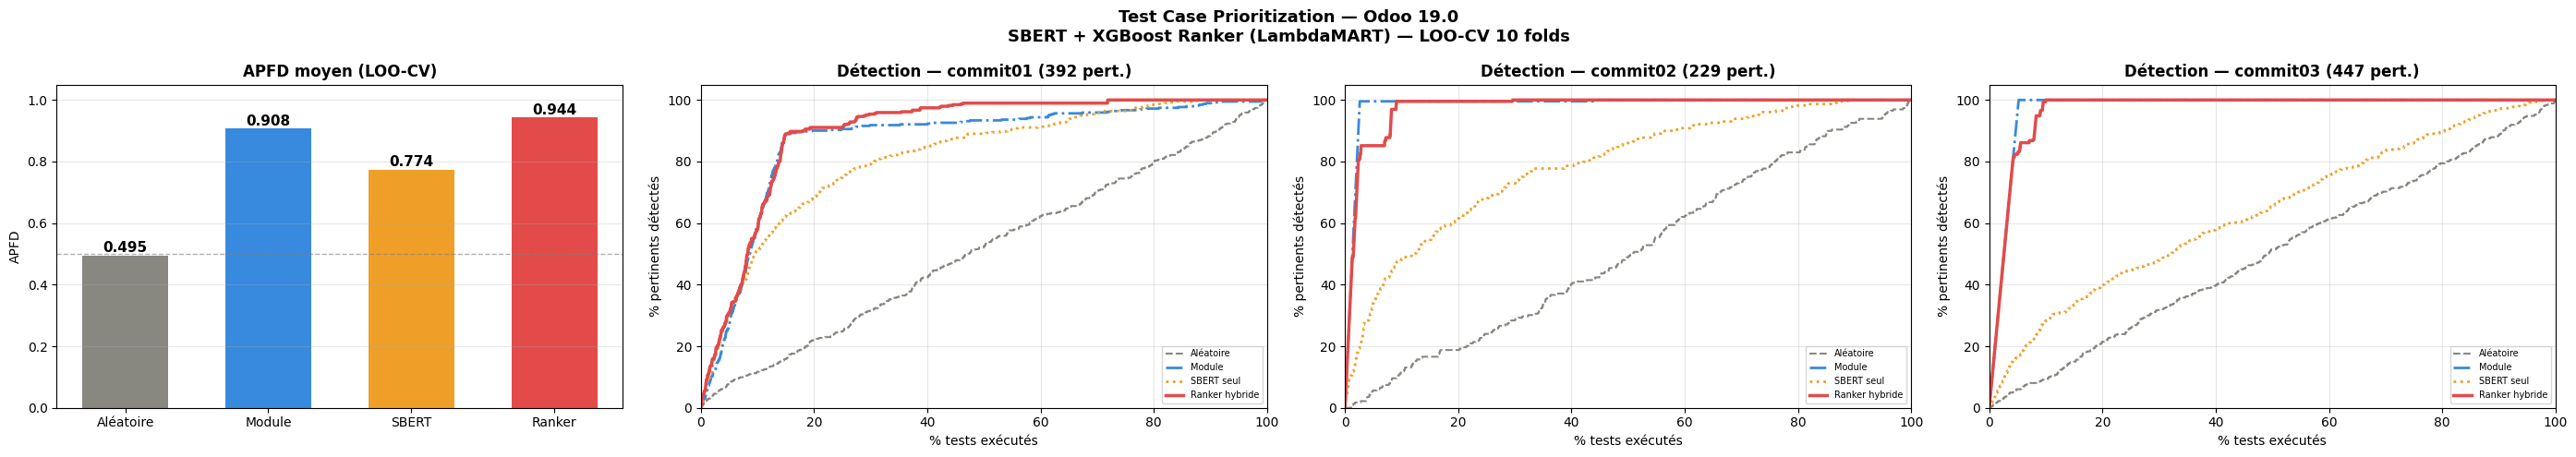

In [9]:
# ÉTAPE 12 : Figure finale
# Palette et noms courts pour le graphique en barres
COLORS = ['#888780', '#378ADD', '#EF9F27', '#E24B4A']
NAMES = ['Aléatoire', 'Module', 'SBERT', 'Ranker']


def det_curve(dc, col):
    """Calcule la courbe de détection des tests pertinents pour une approche.

    Trie les tests par score décroissant selon la colonne donnée, puis calcule
    la proportion cumulée de tests pertinents détectés en fonction de la
    proportion de tests exécutés. C'est la courbe dont l'aire sous-tend l'APFD.

    Args:
        dc: DataFrame d'un commit (paires commit-test).
        col: Colonne de score utilisée pour l'ordonnancement.

    Returns:
        Tuple (x, y) où x est le pourcentage de tests exécutés et y le
        pourcentage de tests pertinents détectés. Deux listes vides si le
        commit ne contient aucun test pertinent.
    """
    dc_s = dc.sort_values(col, ascending=False)
    labs = dc_s['label_relevant'].tolist()
    t = sum(labs)
    if t == 0: return [], []
    return (np.arange(1,len(labs)+1)/len(labs)*100).tolist(), (np.cumsum(labs)/t*100).tolist()


# Styles de tracé (couleur, ligne, épaisseur) propres à chaque approche,
# le ranker hybride étant mis en avant (trait plein, plus épais).
STYLES = [
    ('random_score', 'Aléatoire', '#888780', '--', 1.5),
    ('module_score', 'Module', '#378ADD', '-.', 2.0),
    ('similarity_score', 'SBERT seul', '#EF9F27', ':', 2.0),
    ('rank_score', 'Ranker hybride', '#E24B4A', '-', 2.5),
]

# Sélection des commits à illustrer par une courbe de détection (jusqu'à 3)
valid_folds = [cid for cid in fold_results.keys()]
n_curves = min(3, len(valid_folds))

# Figure composée : 1 graphe de barres (APFD moyen) + n_curves courbes
fig, axes = plt.subplots(1, 1 + n_curves, figsize=(7*(1+n_curves), 5))
# Garantit que axes est toujours un tableau, même avec un seul sous-graphe
if not isinstance(axes, np.ndarray): axes = np.array([axes])

fig.suptitle('Test Case Prioritization — Odoo 19.0\n'
            'SBERT + XGBoost Ranker (LambdaMART) — LOO-CV 10 folds',
            fontsize=13, fontweight='bold')

# 1. Graphe de gauche : APFD moyen de chaque approche sur l'ensemble des folds
means = []
for col, _ in APPROACHES:
    vals = [r[col]['apfd'] for r in fold_results.values()]
    means.append(np.mean(vals) if vals else 0.5)
bars = axes[0].bar(NAMES, means, color=COLORS, width=0.6)
# Ligne de référence à 0.5 (niveau d'un ordonnancement aléatoire)
axes[0].axhline(0.5, color='gray', ls='--', lw=1, alpha=0.6)
axes[0].set_title('APFD moyen (LOO-CV)', fontweight='bold')
axes[0].set_ylabel('APFD'); axes[0].set_ylim(0, 1.05); axes[0].grid(axis='y', alpha=0.3)
# Étiquette de valeur au-dessus de chaque barre
for b, v in zip(bars, means):
    axes[0].text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}',
                ha='center', fontsize=11, fontweight='bold')

# 2-4. Graphes de droite : courbes de détection pour quelques commits.
# Plus une courbe monte vite, plus l'approche détecte tôt les tests pertinents.
for pi, cid in enumerate(valid_folds[:n_curves]):
    dc = df[df.commit_id == cid]
    ax = axes[1 + pi]
    for col, lbl, c, ls, lw in STYLES:
        x, y = det_curve(dc, col)
        if x: ax.plot(x, y, color=c, ls=ls, lw=lw, label=lbl)
    n_pert = dc.label_relevant.sum()
    ax.set_title(f'Détection — {cid} ({n_pert} pert.)', fontweight='bold')
    ax.set_xlabel('% tests exécutés'); ax.set_ylabel('% pertinents détectés')
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(alpha=0.3); ax.set_xlim(0,100); ax.set_ylim(0,105)

plt.tight_layout()
# Sauvegarde de la figure de synthèse pour le mémoire et le package
plt.savefig(os.path.join( ARTIFACTS /'v5_resultats_finaux.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#ÉTAPE 14 : Résumé final
from scipy.stats import spearmanr

print(f'''
━━━ DATASET ━━━
  Commits        : {df.commit_id.nunique()}
  Tests/commit   : ~{len(df)//df.commit_id.nunique():,}
  Total lignes   : {len(df):,}
  Modules        : {df.module.nunique()}
  Features       : {len(FEATURES)}
  Pertinents     : {df.label_relevant.sum():,} ({df.label_relevant.mean()*100:.1f}%)

━━━ PIPELINE ━━━
  Embedding      : SBERT (all-MiniLM-L6-v2, 384 dims)
  Modèle         : XGBoost Ranker (LambdaMART, rank:pairwise)
  Labeling       : Score continu [0-1], 5 niveaux de pertinence
  Validation     : Leave-One-Commit-Out CV ({len(fold_results)} folds)
  Métriques      : APFD + NDCG@20 / @nb_pert / complet

━━━ RÉSULTATS (LOO-CV) ━━━''')

for col, name in APPROACHES:
    apfds = [r[col]['apfd']      for r in fold_results.values()]
    n20   = [r[col]['ndcg20']    for r in fold_results.values()]
    npert = [r[col]['ndcg_pert'] for r in fold_results.values()]
    nfull = [r[col]['ndcg_full'] for r in fold_results.values()]
    if apfds:
        ba = np.mean([r['random_score']['apfd'] for r in fold_results.values()])
        marker = '  ← NOTRE SOLUTION' if col == 'rank_score' else ''
        print(f"  {name:<18}: APFD={np.mean(apfds):.4f} ({(np.mean(apfds)-ba):+.1%})  "
              f"NDCG@20={np.mean(n20):.4f}  NDCG@nb_pert={np.mean(npert):.4f}  "
              f"NDCG_full={np.mean(nfull):.4f}{marker}")

print(f'''
━━━ TOP FEATURES ━━━''')
for f, v in imp.tail(5).items():
    print(f"  {f:<30}: {v:.4f}")

corr, _ = spearmanr(df.similarity_score, df.relevance_score)
print(f'''
━━━ CONTRIBUTION SBERT ━━━
  Corrélation Spearman sim↔pertinence : {corr:.4f}
  Importance similarity_score         : {imp['similarity_score']:.4f} ({imp['similarity_score']/imp.sum()*100:.1f}% du total)

━━━ FICHIERS GÉNÉRÉS ━━━
  {ARTIFACTS / 'v5_dataset_overview.png'}
  {ARTIFACTS / 'v5_similarity.png'}
  {ARTIFACTS / 'v5_feature_importance.png'}
  {ARTIFACTS / 'v5_resultats_finaux.png'}
  {ARTIFACTS / 'v5_fold_analysis.png'}
''')


━━━ DATASET ━━━
  Commits        : 30
  Tests/commit   : ~8,788
  Total lignes   : 263,649
  Modules        : 136
  Features       : 20
  Pertinents     : 10,905 (4.1%)

━━━ PIPELINE ━━━
  Embedding      : SBERT (all-MiniLM-L6-v2, 384 dims)
  Modèle         : XGBoost Ranker (LambdaMART, rank:pairwise)
  Labeling       : Score continu [0-1], 5 niveaux de pertinence
  Validation     : Leave-One-Commit-Out CV (25 folds)
  Métriques      : APFD + NDCG@20 / @nb_pert / complet

━━━ RÉSULTATS (LOO-CV) ━━━
  Aléatoire         : APFD=0.5054 (+0.0%)  NDCG@20=0.0457  NDCG@nb_pert=0.0614  NDCG_full=0.6083
  Module seul       : APFD=0.9151 (+41.0%)  NDCG@20=0.5920  NDCG@nb_pert=0.7581  NDCG_full=0.8946
  SBERT seul        : APFD=0.7738 (+26.8%)  NDCG@20=0.3509  NDCG@nb_pert=0.3155  NDCG_full=0.7467
  Ranker hybride    : APFD=0.9443 (+43.9%)  NDCG@20=0.8966  NDCG@nb_pert=0.8338  NDCG_full=0.9471  ← NOTRE SOLUTION

━━━ TOP FEATURES ━━━
  duration_ms                   : 0.0324
  similarity_score     

## Comparaison avec d'autres modèles


  LightGBM Ranker: APFD = 0.9520 (±0.0475)
                   NDCG@20 = 0.8993

  RankNet:         APFD = 0.9509 (±0.0525)
                   NDCG@20 = 0.9292

RÉSUMÉ COMPARATIF — 3 MODÈLES DE RANKING

  Modèle                   APFD     ±Std   NDCG@20 Type              
----------------------------------------------------------------------
  RankNet                0.9509   0.0525    0.9292 Réseau pairwise   
  LightGBM Ranker        0.9520   0.0475    0.8993 Ranker listwise   
  XGBoost Ranker         0.9443   0.0628    0.8966 Ranker listwise    ← MEILLEUR


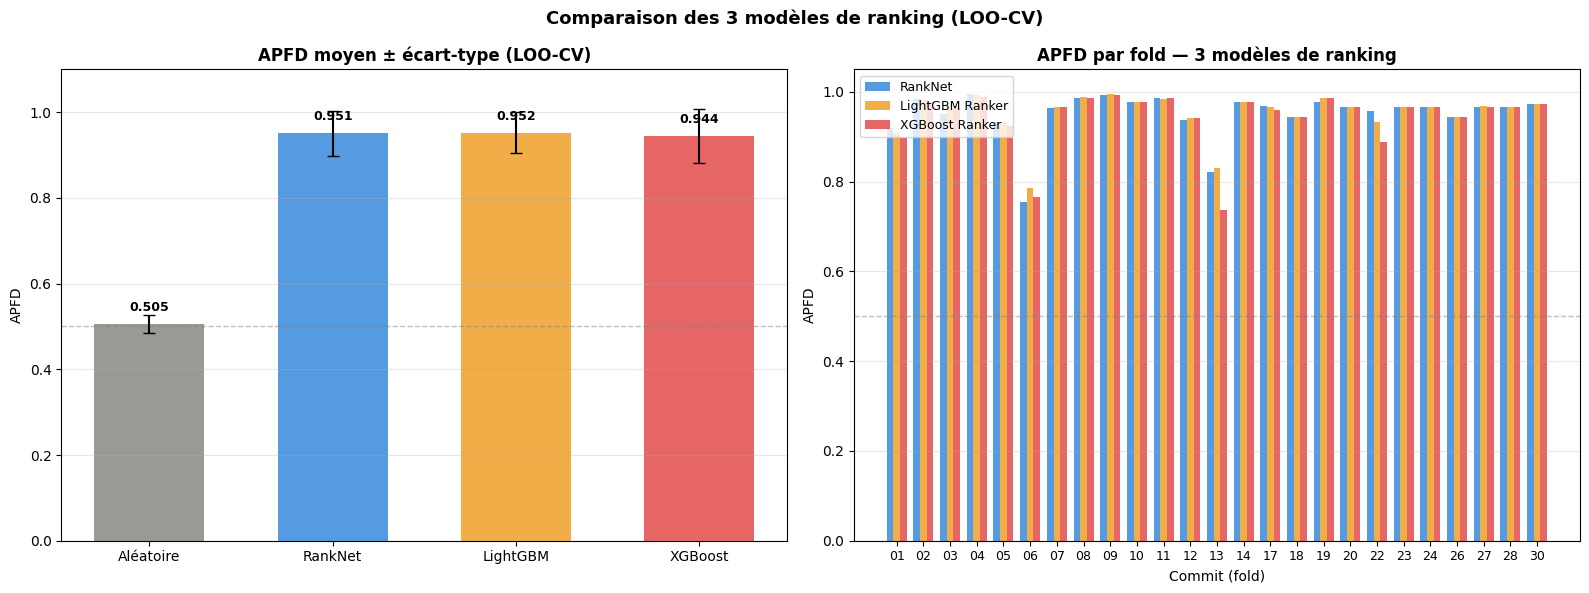

In [ ]:
# ÉTAPE 10c : Ajout LightGBM Ranker + RankNet 
import lightgbm as lgb

# 1. LightGBM Ranker — même protocole LOO-CV que XGBoost, pour une comparaison équitable
lgbm_apfds = []
lgbm_ndcgs = []

for test_cid in commit_ids:
    df_tr = df[df.commit_id != test_cid].copy()
    df_te = df[df.commit_id == test_cid].copy()
    # Même filtre que pour XGBoost : on écarte les commits sans labels mixtes
    if df_te.label_relevant.sum() == 0 or df_te.label_relevant.nunique() < 2:
        continue

    X_tr = df_tr[FEATURES].values
    y_tr = df_tr['relevance_score'].apply(score_to_grade).values
    X_te = df_te[FEATURES].values
    tr_groups = df_tr.groupby('commit_id').size().values

    # Hyperparamètres alignés sur ceux de XGBoost pour une comparaison à conditions égales
    lgbm_ranker = lgb.LGBMRanker(
        objective='lambdarank', n_estimators=200, max_depth=3,
        learning_rate=0.05, subsample=0.7, colsample_bytree=0.7,
        reg_alpha=1.0, reg_lambda=2.0, min_child_samples=10,
        random_state=42, verbosity=-1,
    )
    lgbm_ranker.fit(X_tr, y_tr, group=tr_groups)
    preds = lgbm_ranker.predict(X_te)

    # Évaluation du fold : APFD et NDCG@20
    dc = df_te.copy()
    dc['lgbm_score'] = preds
    ordered = dc.sort_values('lgbm_score', ascending=False)['label_relevant'].tolist()
    lgbm_apfds.append(compute_apfd(ordered))
    lgbm_ndcgs.append(safe_ndcg(dc['relevance_score'].values, dc['lgbm_score'].values, k=20))

print(f"\n  LightGBM Ranker: APFD = {np.mean(lgbm_apfds):.4f} (±{np.std(lgbm_apfds):.4f})")
print(f"                   NDCG@20 = {np.mean(lgbm_ndcgs):.4f}")


# 2. RankNet — réseau de neurones pairwise pour le ranking
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim


class RankNet(nn.Module):
    """Réseau de neurones pour le ranking (architecture Base à 2 couches cachées).

    Le réseau projette le vecteur de features (dimension input_dim) vers un
    score scalaire, via deux couches cachées de 64 puis 32 neurones avec
    activation ReLU et Dropout (régularisation). Le même réseau (mêmes poids)
    est appliqué à chaque test ; l'ordre s'apprend via une perte pairwise.
    """
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)


def ranknet_loss(scores, labels):
    """Perte pairwise de RankNet sur un échantillon de paires.

    Forme des paires (test pertinent, test non pertinent) et pénalise les cas
    où le test pertinent reçoit un score inférieur. Pour limiter le coût, un
    sous-ensemble de paires est échantillonné aléatoirement (au plus 500).

    Args:
        scores: Scores prédits par le réseau pour les tests du commit.
        labels: Labels binaires (1 = pertinent, 0 sinon).

    Returns:
        Perte moyenne sur les paires échantillonnées (tenseur scalaire).
        Retourne 0 si une des deux classes est absente (aucune paire possible).
    """
    loss = torch.tensor(0.0, requires_grad=True)
    idx_pos = (labels == 1).nonzero(as_tuple=True)[0]
    idx_neg = (labels == 0).nonzero(as_tuple=True)[0]
    if len(idx_pos) == 0 or len(idx_neg) == 0:
        return loss
    n_pairs = min(500, len(idx_pos) * len(idx_neg))
    pos_sample = idx_pos[torch.randint(len(idx_pos), (n_pairs,))]
    neg_sample = idx_neg[torch.randint(len(idx_neg), (n_pairs,))]
    diff = scores[pos_sample] - scores[neg_sample]
    # log(1 + exp(-(s_pos - s_neg))) : perte logistique pairwise de RankNet
    return torch.mean(torch.log1p(torch.exp(-diff)))


ranknet_apfds = []
ranknet_ndcgs = []
scaler = StandardScaler()

for test_cid in commit_ids:
    df_tr = df[df.commit_id != test_cid].copy()
    df_te = df[df.commit_id == test_cid].copy()
    if df_te.label_relevant.sum() == 0 or df_te.label_relevant.nunique() < 2:
        continue

    # Normalisation des features (indispensable pour un réseau de neurones) :
    # le scaler est ajusté sur l'entraînement puis appliqué au test (pas de fuite).
    X_tr = scaler.fit_transform(df_tr[FEATURES].values)
    y_tr = df_tr['label_relevant'].values
    X_te = scaler.transform(df_te[FEATURES].values)

    X_tr_t = torch.FloatTensor(X_tr)
    y_tr_t = torch.FloatTensor(y_tr)
    X_te_t = torch.FloatTensor(X_te)

    # Entraînement du réseau sur 100 époques (descente de gradient Adam)
    model = RankNet(len(FEATURES))
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

    model.train()
    for epoch in range(100):
        optimizer.zero_grad()
        scores = model(X_tr_t)
        loss = ranknet_loss(scores, y_tr_t)
        loss.backward()
        optimizer.step()

    # Prédiction sur le commit de test (mode évaluation, sans gradient)
    model.eval()
    with torch.no_grad():
        preds = model(X_te_t).numpy()

    dc = df_te.copy()
    dc['ranknet_score'] = preds
    ordered = dc.sort_values('ranknet_score', ascending=False)['label_relevant'].tolist()
    ranknet_apfds.append(compute_apfd(ordered))
    ranknet_ndcgs.append(safe_ndcg(dc['relevance_score'].values, dc['ranknet_score'].values, k=20))

print(f"\n  RankNet:         APFD = {np.mean(ranknet_apfds):.4f} (±{np.std(ranknet_apfds):.4f})")
print(f"                   NDCG@20 = {np.mean(ranknet_ndcgs):.4f}")


# 3. Tableau comparatif des 3 rankers.
# Les scores XGBoost sont récupérés depuis fold_results (boucle principale),
# afin de comparer les trois modèles sur exactement les mêmes folds.
xgb_apfds = [fold_results[c]['rank_score']['apfd'] for c in fold_results]
xgb_ndcgs = [fold_results[c]['rank_score']['ndcg20'] for c in fold_results]


print('RÉSUMÉ COMPARATIF — 3 MODÈLES DE RANKING')

rankers = {
    'RankNet':         (ranknet_apfds, ranknet_ndcgs, 'Réseau pairwise'),
    'LightGBM Ranker': (lgbm_apfds,    lgbm_ndcgs,    'Ranker listwise'),
    'XGBoost Ranker':  (xgb_apfds,     xgb_ndcgs,     'Ranker listwise'),
}
for name, (apfds, ndcgs, mtype) in rankers.items():
    m, s = np.mean(apfds), np.std(apfds)
    n = np.mean(ndcgs) if ndcgs else 0
    print(f"  {name:<20} {m:>8.4f} {s:>8.4f} {n:>9.4f} {mtype:<18}")

# 4. Visualisation comparative : barres APFD moyen (gauche) + APFD par fold (droite)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphe de gauche : APFD moyen des 3 rankers, avec l'aléatoire comme repère
random_apfds = [fold_results[c]['random_score']['apfd'] for c in fold_results]
names_3  = ['Aléatoire', 'RankNet', 'LightGBM', 'XGBoost']
means_3  = [np.mean(random_apfds), np.mean(ranknet_apfds), np.mean(lgbm_apfds), np.mean(xgb_apfds)]
stds_3   = [np.std(random_apfds),  np.std(ranknet_apfds),  np.std(lgbm_apfds),  np.std(xgb_apfds)]
colors_3 = ['#888780', '#378ADD', '#EF9F27', '#E24B4A']

bars = axes[0].bar(names_3, means_3, yerr=stds_3, capsize=4, color=colors_3, width=0.6, alpha=0.85)
axes[0].axhline(0.5, color='gray', ls='--', lw=1, alpha=0.5)
axes[0].set_ylabel('APFD')
axes[0].set_title('APFD moyen ± écart-type (LOO-CV)', fontweight='bold')
axes[0].set_ylim(0, 1.1)
axes[0].grid(axis='y', alpha=0.3)
for b, m in zip(bars, means_3):
    axes[0].text(b.get_x() + b.get_width()/2, m + 0.03, f'{m:.3f}',
                ha='center', fontsize=9, fontweight='bold')

# Graphe de droite : APFD commit par commit, pour visualiser la stabilité
# de chaque modèle d'un fold à l'autre.
valid_folds = list(fold_results.keys())
x = np.arange(len(valid_folds))
w = 0.25
axes[1].bar(x - w, ranknet_apfds, w, label='RankNet', color='#378ADD', alpha=0.85)
axes[1].bar(x,     lgbm_apfds,    w, label='LightGBM Ranker', color='#EF9F27', alpha=0.85)
axes[1].bar(x + w, xgb_apfds,     w, label='XGBoost Ranker', color='#E24B4A', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels([c[-2:] for c in valid_folds], fontsize=9)
axes[1].set_xlabel('Commit (fold)')
axes[1].set_ylabel('APFD')
axes[1].set_title('APFD par fold — 3 modèles de ranking', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].axhline(0.5, color='gray', ls='--', lw=1, alpha=0.5)
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(0, 1.05)

plt.suptitle('Comparaison des 3 modèles de ranking (LOO-CV)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(ARTIFACTS / 'v5_rankers_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

COMPARAISON ARCHITECTURES RANKNET (LOO-CV)

── Shallow (1 couche, 32n) ──
  APFD = 0.9514 (±0.0362)
  NDCG@20 = 0.9181
  Paramètres = 705

── Base (2 couches, 64→32) ──
  APFD = 0.9554 (±0.0359)
  NDCG@20 = 0.9373
  Paramètres = 3,457

── Deep (4 couches, 128→64→32→16) ──
  APFD = 0.9537 (±0.0407)
  NDCG@20 = 0.8929
  Paramètres = 13,953

── Very Deep (6 couches, 256→128→64→32→16) ──
  APFD = 0.9488 (±0.0582)
  NDCG@20 = 0.9036
  Paramètres = 50,049

RÉSUMÉ — ARCHITECTURES RANKNET

  Architecture                          Params     APFD     ±Std   NDCG@20
  ------------------------------------------------------------------------
  Shallow (1 couche, 32n)                  705   0.9514   0.0362    0.9181
  Base (2 couches, 64→32)                3,457   0.9554   0.0359    0.9373 ←
  Deep (4 couches, 128→64→32→16)        13,953   0.9537   0.0407    0.8929
  Very Deep (6 couches, 256→128→64→32→16)   50,049   0.9488   0.0582    0.9036


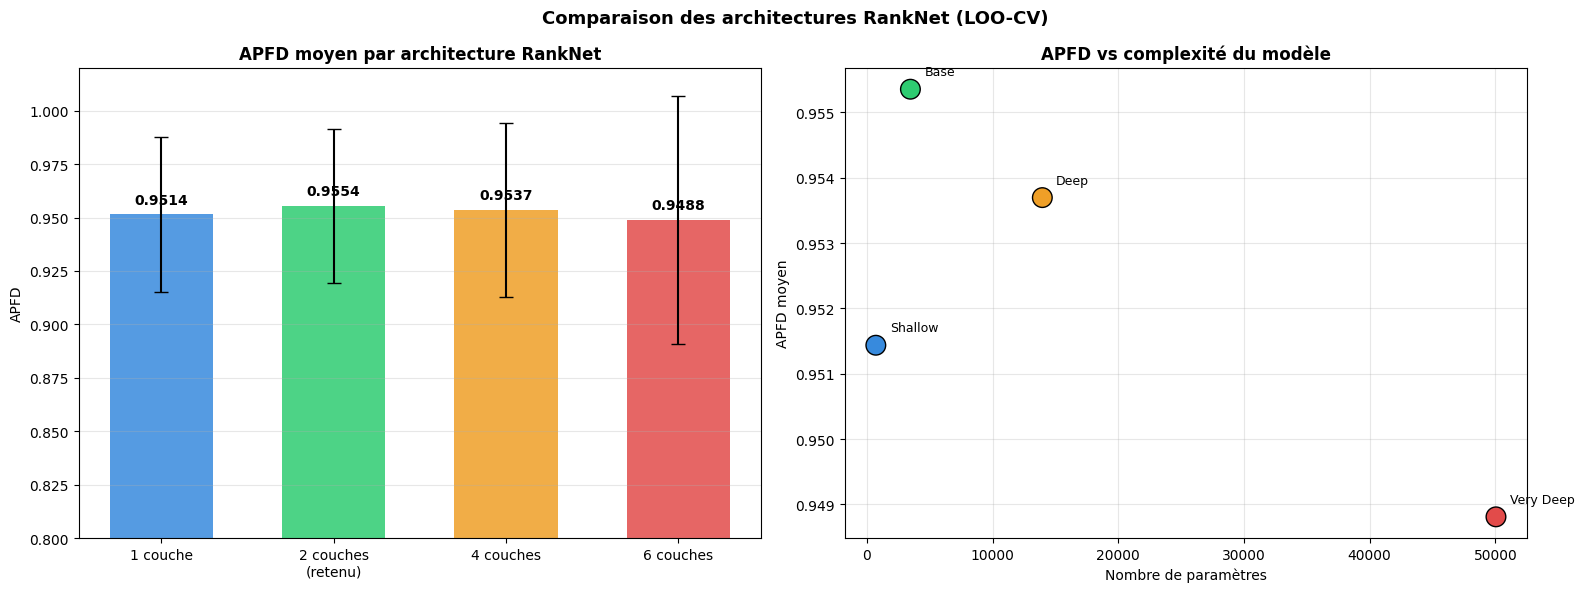

In [ ]:
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim


# ── ÉTAPE 10d : Comparaison d'architectures RankNet ──────────
# Objectif : évaluer si une architecture plus profonde améliore les performances,
# en comparant quatre profondeurs de réseau dans le même protocole LOO-CV.
print('=' * 75)
print('COMPARAISON ARCHITECTURES RANKNET (LOO-CV)')
print('=' * 75)


class RankNetShallow(nn.Module):
    """RankNet superficiel : une seule couche cachée (32 neurones)."""
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)


class RankNetBase(nn.Module):
    """RankNet de base : deux couches cachées (64 puis 32). Architecture retenue."""
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)


class RankNetDeep(nn.Module):
    """RankNet profond : quatre couches cachées (128→64→32→16) avec BatchNorm."""
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)


class RankNetVeryDeep(nn.Module):
    """RankNet très profond : six couches cachées (256→128→64→32→16) avec BatchNorm."""
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)


# Dictionnaire des architectures à évaluer (du plus simple au plus profond)
ARCHITECTURES = {
    'Shallow (1 couche, 32n)': RankNetShallow,
    'Base (2 couches, 64→32)': RankNetBase,
    'Deep (4 couches, 128→64→32→16)': RankNetDeep,
    'Very Deep (6 couches, 256→128→64→32→16)': RankNetVeryDeep,
}

arch_results = {}

# Pour chaque architecture, on déroule la validation LOO-CV complète
for arch_name, arch_class in ARCHITECTURES.items():
    print(f"\n── {arch_name} ──")
    fold_apfds = []
    fold_ndcgs = []
    scaler_arch = StandardScaler()

    for test_cid in commit_ids:
        df_tr = df[df.commit_id != test_cid].copy()
        df_te = df[df.commit_id == test_cid].copy()

        # Même filtre que partout : commits sans labels mixtes écartés
        if df_te.label_relevant.sum() == 0 or df_te.label_relevant.nunique() < 2:
            continue

        # Normalisation ajustée sur le train, appliquée au test (pas de fuite)
        X_tr = scaler_arch.fit_transform(df_tr[FEATURES].values)
        y_tr = df_tr['label_relevant'].values
        X_te = scaler_arch.transform(df_te[FEATURES].values)

        X_tr_t = torch.FloatTensor(X_tr)
        y_tr_t = torch.FloatTensor(y_tr)
        X_te_t = torch.FloatTensor(X_te)

        # Entraînement (100 époques, Adam) avec la perte pairwise commune
        model = arch_class(len(FEATURES))
        optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

        model.train()
        for epoch in range(100):
            optimizer.zero_grad()
            scores = model(X_tr_t)
            loss = ranknet_loss(scores, y_tr_t)
            loss.backward()
            optimizer.step()

        # Prédiction et évaluation du fold (APFD + NDCG@20)
        model.eval()
        with torch.no_grad():
            preds = model(X_te_t).numpy()

        dc = df_te.copy()
        dc['pred_score'] = preds
        ordered = dc.sort_values('pred_score', ascending=False)['label_relevant'].tolist()
        fold_apfds.append(compute_apfd(ordered))

        try:
            ndcg = ndcg_score(dc['relevance_score'].values.reshape(1,-1),
                            dc['pred_score'].values.reshape(1,-1), k=20)
        except: ndcg = 0.0
        fold_ndcgs.append(ndcg)

    # Agrégation des résultats + comptage des paramètres du modèle
    arch_results[arch_name] = {
        'apfds': fold_apfds,
        'ndcgs': fold_ndcgs,
        'mean_apfd': np.mean(fold_apfds),
        'std_apfd': np.std(fold_apfds),
        'mean_ndcg': np.mean(fold_ndcgs),
        'n_params': sum(p.numel() for p in arch_class(len(FEATURES)).parameters()),
    }

    print(f"  APFD = {np.mean(fold_apfds):.4f} (±{np.std(fold_apfds):.4f})")
    print(f"  NDCG@20 = {np.mean(fold_ndcgs):.4f}")
    print(f"  Paramètres = {arch_results[arch_name]['n_params']:,}")

# ── Tableau récapitulatif (le ← marque la meilleure APFD) ──
print('RÉSUMÉ — ARCHITECTURES RANKNET')
print(f"\n  {'Architecture':<35} {'Params':>8} {'APFD':>8} {'±Std':>8} {'NDCG@20':>9}")
for name, r in arch_results.items():
    marker = ' ←' if r['mean_apfd'] == max(v['mean_apfd'] for v in arch_results.values()) else ''
    print(f"  {name:<35} {r['n_params']:>8,} {r['mean_apfd']:>8.4f} "
          f"{r['std_apfd']:>8.4f} {r['mean_ndcg']:>9.4f}{marker}")

# ── Visualisation : APFD par architecture + APFD vs complexité ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

names = list(arch_results.keys())
apfds = [arch_results[n]['mean_apfd'] for n in names]
stds = [arch_results[n]['std_apfd'] for n in names]
params = [arch_results[n]['n_params'] for n in names]
colors = ['#378ADD', '#2ecc71', '#EF9F27', '#E24B4A']

# Graphe de gauche : APFD moyen ± écart-type pour chaque profondeur
bars = axes[0].bar(range(len(names)), apfds, yerr=stds, capsize=5,
                    color=colors, width=0.6, alpha=0.85)
axes[0].set_xticks(range(len(names)))
axes[0].set_xticklabels(['1 couche', '2 couches\n(retenu)', '4 couches', '6 couches'], fontsize=10)
axes[0].set_ylabel('APFD')
axes[0].set_title('APFD moyen par architecture RankNet', fontweight='bold')
axes[0].set_ylim(0.8, 1.02)
axes[0].grid(axis='y', alpha=0.3)
for b, m in zip(bars, apfds):
    axes[0].text(b.get_x() + b.get_width()/2, m + 0.005,
                 f'{m:.4f}', ha='center', fontsize=10, fontweight='bold')

# Graphe de droite : APFD en fonction du nombre de paramètres.
# Illustre que la complexité supplémentaire n'apporte pas de gain (voire nuit).
axes[1].scatter(params, apfds, s=200, c=colors, zorder=5, edgecolors='black')
for i, name in enumerate(names):
    label = name.split('(')[0].strip()
    axes[1].annotate(label, (params[i], apfds[i]),
                     textcoords="offset points", xytext=(10, 10), fontsize=9)
axes[1].set_xlabel('Nombre de paramètres')
axes[1].set_ylabel('APFD moyen')
axes[1].set_title('APFD vs complexité du modèle', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.suptitle('Comparaison des architectures RankNet (LOO-CV)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join( ARTIFACTS / 'v5_ranknet_architectures.png'), dpi=150, bbox_inches='tight')
plt.show()

## Entraînement du modèle Rankent + sauvegarde
Le ranker est entraîné sur **tous** les commits puis sauvegardé, pour que les notebooks 04 et 05 le rechargent sans réentraîner.

In [ ]:
import joblib, torch

# Dossier de sauvegarde des modèles (créé s'il n'existe pas)
MODELS_DIR = ROOT / 'models'
MODELS_DIR.mkdir(exist_ok=True)

# ── Réentraîner RankNet "Base" (2 couches) sur TOUT le dataset ──
# Contrairement à la LOO-CV (qui entraîne un modèle par fold), on entraîne ici
# un modèle unique sur l'intégralité des données. Ce modèle "complet" sert
# uniquement à la validation par mutations, où il est appliqué à des diffs
# artificiels externes (pas de fuite, car les mutations ne font pas partie
# du dataset d'entraînement).
scaler_ranknet = StandardScaler()
X_full = scaler_ranknet.fit_transform(df[FEATURES].values)
y_full = df['label_relevant'].values
X_full_t = torch.FloatTensor(X_full)
y_full_t = torch.FloatTensor(y_full)

# Entraînement du réseau Base sur l'ensemble du dataset (100 époques, Adam)
ranknet_full = RankNetBase(len(FEATURES))
optimizer = optim.Adam(ranknet_full.parameters(), lr=0.001, weight_decay=1e-4)
ranknet_full.train()
for epoch in range(100):
    optimizer.zero_grad()
    loss = ranknet_loss(ranknet_full(X_full_t), y_full_t)
    loss.backward()
    optimizer.step()

print("RankNet (Base, 2 couches) entraîné sur l'ensemble du dataset")

## Entraînement des modèles Xgboost et lightgbm + sauvegarde
Le ranker est entraîné sur **tous** les commits puis sauvegardé, pour que les notebooks 04 et 05 le rechargent sans réentraîner.

In [10]:
import joblib, pickle, torch
from pathlib import Path
import lightgbm as lgb

ROOT = Path.cwd()
if ROOT.name == 'scripts': ROOT = ROOT.parent
MODELS_DIR = ROOT / 'models'
ARTIFACTS = ROOT / 'artifacts'
MODELS_DIR.mkdir(exist_ok=True)

# XGBoost Ranker ──
X_all = df[FEATURES].values
y_all = df['relevance_score'].apply(score_to_grade).values
all_groups = df.groupby('commit_id').size().values

ranker_full = xgb.XGBRanker(
    objective='rank:pairwise', n_estimators=200, max_depth=3,
    learning_rate=0.05, subsample=0.7, colsample_bytree=0.7,
    reg_alpha=1.0, reg_lambda=2.0, min_child_weight=10,
    random_state=42, verbosity=0,
)
ranker_full.fit(X_all, y_all, group=all_groups, verbose=False)

# ── LightGBM Ranker entraîné sur tout le dataset ──
lgbm_full = lgb.LGBMRanker(
    objective='lambdarank', n_estimators=200, max_depth=3,
    learning_rate=0.05, subsample=0.7, colsample_bytree=0.7,
    reg_alpha=1.0, reg_lambda=2.0, min_child_samples=10,
    random_state=42, verbosity=-1,
)
lgbm_full.fit(X_all, y_all, group=all_groups)
# Sauvegarde du modèle XGBoost + liste de features
joblib.dump(ranker_full, MODELS_DIR / 'xgboost_ranker.pkl')
pickle.dump(FEATURES, open(MODELS_DIR / 'feature_list.pkl', 'wb'))
print(' xgboost_ranker.pkl sauvegardé')

# light gbm
if 'lgbm_full' in dir():
    joblib.dump(lgbm_full, MODELS_DIR / 'lightgbm_ranker.pkl')
    print(' lightgbm_ranker.pkl sauvegardé')
#rnaknet (réseaux neuronnes)
if 'ranknet_full' in dir():
    torch.save(ranknet_full.state_dict(), MODELS_DIR / 'ranknet_model.pt')
    print(' ranknet_model.pt sauvegardé')
    if 'scaler_ranknet' in dir():
        joblib.dump(scaler_ranknet, MODELS_DIR / 'ranknet_scaler.pkl')
        print(' ranknet_scaler.pkl sauvegardé')

df.to_pickle(ARTIFACTS / 'dataset_scored.pkl')
print('Dataset scoré sauvegardé')

 xgboost_ranker.pkl sauvegardé
 lightgbm_ranker.pkl sauvegardé
Dataset scoré sauvegardé
